## Brender-Assignment on Correlation and Regression Analysis

### 1. Analyze Relationships Between Variables: Use correlation analysis to measure relationships between variables in a dataset(car).
### 2. Build simple and multiple linear regression models to analyze the impact of independent variables on a dependent variable.
### 3. Interpret the regression coefficients, R-squared, and p-values.
### 4. Perform model diagnostics to check assumptions and detect multicollinearity.

In [35]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

mt = pd.read_csv("mtcars (1).csv")
mt.head(5)

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945.0,33337.0,3.5,6.0,265,17,23,4451,106,189
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820.0,21761.0,2.0,4.0,200,24,31,2778,101,172
2,Acura,TSX 4dr,Sedan,Asia,Front,26990.0,24647.0,2.4,4.0,200,22,29,3230,105,183
3,Acura,TL 4dr,Sedan,Asia,Front,33195.0,30299.0,3.2,6.0,270,20,28,3575,108,186
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755.0,39014.0,3.5,6.0,225,18,24,3880,115,197


In [36]:
from scipy.stats import pearsonr

r, p_value = pearsonr(mt["MPG_City"], mt["Weight"])
print(f"Pearson correlation coefficient:{r:.3f}")
print(f"p-value:{p_value:.3f}")

Pearson correlation coefficient:-0.738
p-value:0.000


In [37]:
from scipy.stats import pearsonr

r, p_value = pearsonr(mt["MPG_City"], mt["Wheelbase"])
print(f"Pearson correlation coefficient:{r:.3f}")
print(f"p-value:{p_value:.3f}")

Pearson correlation coefficient:-0.507
p-value:0.000


## Simple Linear Regression model

In [38]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Define X and y
X = mt[['MPG_City']]  # 2D for sklearn
y = mt['Horsepower']

# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# Print coefficient and intercept
print("Intercept:", model.intercept_)
print("Slope (MPG_City):", model.coef_[0])

# Predict malaria cases
y_pred = model.predict(X)
#print("Predicted values:", y_pred)


Intercept: 402.0520612894917
Slope (MPG_City): -9.28014002235062


In [31]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Sample data
df = pd.DataFrame({
    'MPG_City': [17,24,22,20,18],
    'Cylinders': [6.0,4.0,4.0,6.0,6.0]
})

# Define X and y
X = df[['MPG_City']]  # 2D for sklearn
y = df['Cylinders']

# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# Print coefficient and intercept
print("Intercept:", model.intercept_)
print("Slope (MPG_City):", model.coef_[0])

# Predict malaria cases
y_pred = model.predict(X)
print("Predicted values:", y_pred)


Intercept: 12.097560975609758
Slope (MPG_City): -0.3414634146341464
Predicted values: [6.29268293 3.90243902 4.58536585 5.26829268 5.95121951]


## Multiple Linear Regression Model

In [41]:
import statsmodels.api as sm
x = mt[["EngineSize", "Cylinders", "Horsepower", "Weight", "Wheelbase", "Length"]]
y = mt["MPG_Highway"]

x = x.fillna(x.mean())

x = sm.add_constant(x)
model=sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MPG_Highway   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     145.0
Date:                Thu, 14 May 2026   Prob (F-statistic):           3.90e-99
Time:                        14:45:24   Log-Likelihood:                -1115.1
No. Observations:                 428   AIC:                             2244.
Df Residuals:                     421   BIC:                             2273.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.3685      2.757     13.917      0.0

# Testing the Assumptions of Classical Linear Regression Models
## 1.A plot of Residuals Vs Fitted

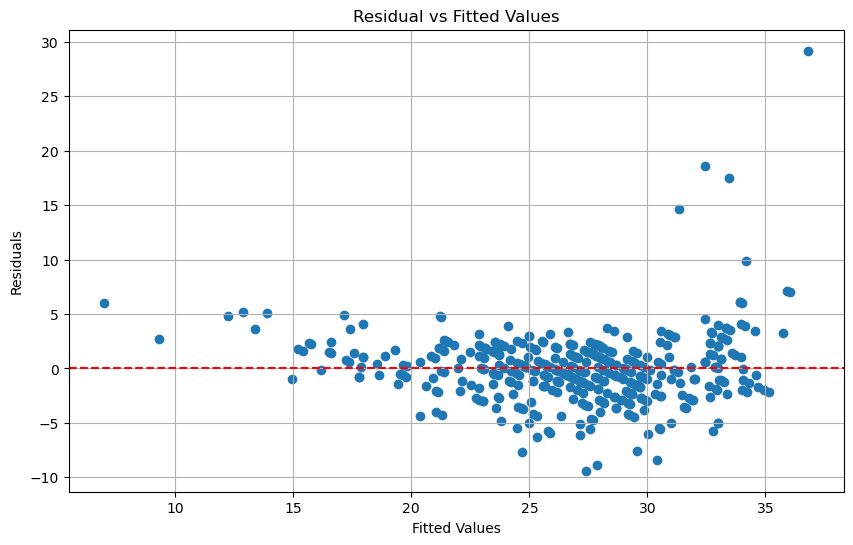

In [42]:
import matplotlib.pyplot as plt
residuals = model.resid

plt.figure(figsize =(10,6))
plt.scatter(model.fittedvalues,residuals)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted Values')
plt.grid(True)
plt.show()

## Multicollinearity Check(Variance Inflation Factor-VIF):

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["variable"]=x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_data

,variable,VIF
0,const,298.317962
1,EngineSize,7.809665
2,Cylinders,6.260491
3,Horsepower,3.293489
4,Weight,4.223036
5,Wheelbase,6.154157
6,Length,5.088825
